## Python Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
prices_url = "https://docs.google.com/spreadsheets/d/1L_6RdRrx7_YTE_CJylbEa4C2SSOyTCAcYpvZmWjxWKU/export?format=csv&gid=1770631224"

securities_url = "https://docs.google.com/spreadsheets/d/1IyBA35-JeW6kMz0Hg7Nt3yIgubL7MYjFiwiP3VtIfAU/export?format=csv&gid=419775033"

fundamentals_url = "https://docs.google.com/spreadsheets/d/1PIqzHpGnZsAVYidHypuwRNZGQMRJS6qBLrUB2cBUPtc/export?format=csv&gid=1590896818"

prices_adj_url = "https://docs.google.com/spreadsheets/d/12tpulyKduDnDnoFrYKYIQVzoj6g8L52bGhXzeuSkduc/export?format=csv&gid=1793531899"


prices = pd.read_csv(prices_url)
securities = pd.read_csv(securities_url)
fundamentals = pd.read_csv(fundamentals_url)
prices_adj = pd.read_csv(prices_adj_url)

print(prices.shape)
print(securities.shape)
print(fundamentals.shape)
print(prices_adj.shape)

(217503, 7)
(150, 7)
(592, 331)
(217503, 7)


### 1. Company Entry and Exit Analysis

In [39]:
# 'date' (sana)ustunidagi matnli qiymatlarni Pandas tushunadigan maxsus vaqt formatiga o'tkazamiz
prices['date'] = pd.to_datetime(prices['date'])
prices_adj['date'] = pd.to_datetime(prices_adj['date'])

# Datasetdagi eng birinchi savdo sanasini topamiz
start_date = prices['date'].min()

# Datasetdagi eng oxirgi savdo sanasini topamiz
end_date = prices['date'].max()

print(f"Dataset date range: {start_date} to {end_date}")

# Har bir kompaniya bo'yicha guruhlaymiz
# va ularning eng birinchi savdo sanasini topamiz
company_first_dates = prices.groupby('symbol')['date'].min()



# Dataset boshlangan kundan keyin paydo bo'lgan kompaniyalarni ajratib olamiz.
# Bular new listings hisoblanadi.
newly_listed = company_first_dates[company_first_dates > start_date]


print(f"\nNewly listed companies (after {start_date}): {len(newly_listed)}")
for company, date in newly_listed.items():
  print(f"  {company}: started on {date}")


# Har bir kompaniyaning eng oxirgi savdo sanasini topamiz
company_last_dates = prices.groupby('symbol')['date'].max()



# Dataset tugashidan oldin savdodan chiqqan kompaniyalarni topamiz.
# Bu delisted yoki bankrupt kompaniyalar bo'lishi mumkin.
ceased_trading = company_last_dates[company_last_dates < end_date]
print(f"\nCompanies that ceased trading (before {end_date}): {len(ceased_trading)}")
for company, date in ceased_trading.items():
  print(f"  {company}: last traded on {date}")

Dataset date range: 2019-01-02 00:00:00 to 2024-12-30 00:00:00

Newly listed companies (after 2019-01-02 00:00:00): 16
  AFRM: started on 2021-01-13 00:00:00
  COIN: started on 2021-04-14 00:00:00
  CRWD: started on 2019-06-12 00:00:00
  DASH: started on 2020-12-09 00:00:00
  HOOD: started on 2021-07-29 00:00:00
  LCID: started on 2020-09-18 00:00:00
  LYFT: started on 2019-03-29 00:00:00
  NET: started on 2019-09-13 00:00:00
  PINS: started on 2019-04-18 00:00:00
  PLTR: started on 2020-09-30 00:00:00
  RIVN: started on 2021-11-10 00:00:00
  SNOW: started on 2020-09-16 00:00:00
  SOFI: started on 2021-01-04 00:00:00
  UBER: started on 2019-05-10 00:00:00
  UPST: started on 2020-12-16 00:00:00
  ZM: started on 2019-04-18 00:00:00

Companies that ceased trading (before 2024-12-30 00:00:00): 0


### 2. Company Ranking and Selection

Market Cap=Share Price × Shares Outstanding

In [41]:
market_cap_data = prices.groupby('symbol').apply(lambda x: (x['close'] * x['volume']).mean()).sort_values(ascending=False)

# 1) Har bir kompaniya (symbol) bo'yicha malumotlarni guruhlaymiz
# 2) Har bir kun uchun Trading Value = close × volume hisoblaymiz
# 3) shu kompaniyaning barcha kunlar bo'yicha o'rtacha Trading Value qiymatini olamiz
# 4) Natijalarni eng katta qiymatdan eng kichik qiymatga qarab saralaymiz

print("Top 20 companies by market cap proxy:")
print(market_cap_data.head(20))

Top 20 companies by market cap proxy:
symbol
NVDA     1.500768e+11
AMZN     1.243117e+11
TSLA     6.493829e+10
GOOGL    3.831298e+10
AAPL     1.893375e+10
AVGO     1.414621e+10
SHOP     8.848205e+09
MSFT     7.167678e+09
AMD      5.765361e+09
META     5.604320e+09
WMT      2.781972e+09
NFLX     2.585116e+09
BA       2.349683e+09
JPM      1.739410e+09
BAC      1.656669e+09
V        1.648806e+09
XOM      1.576771e+09
COIN     1.517576e+09
INTC     1.517100e+09
UNH      1.462993e+09
dtype: float64


Biz kompaniyalarni ranking qilish uchun average trading value dan foydalandik. Trading value aksiya narxi va savdo hajmining ko'paytmasi bo'lib, bozorda qancha pul aylanganini ko'rsatadi. Trading value qanchalik katta bo'lsa, kompaniya aksiyasi shunchalik faol savdo qilinayotgan hisoblanadi. Shu sababli eng yuqori trading value ga ega kompaniyalar Top N kompaniyalar sifatida tanlandi.

### 3. Stock Split Identification

Stock Split: Kompaniya aksiya sonini ko'paytiradi, lekin kompaniyaning umumiy qiymati o'zgarmaydi.

Masalan kompaniyada 10 ta aksiya bor, har biri $100, total = $1000

2 for 1 split:

Oldin:
10 ta aksiya × $100

Keyin:
20 ta aksiya × $50

In [45]:
merged_prices = pd.merge(
      prices[['date', 'symbol', 'close']].rename(columns={'close': 'close_raw'}),
      # prices datasetidan faqat date, symbol va close ustunlarini tanlaymiz
      # close ustunining nomini close_raw ga o'zgartiramiz, chunki bu oddiy (raw) narxlar hisoblanadi
      prices_adj[['date', 'symbol', 'close']].rename(columns={'close': 'close_adj'}),
      # prices_adj datasetidan ham date, symbol va close ustunlarini tanlaymiz
      # Bu yerdagi close ustunini close_adj deb nomlaymiz,
      # chunki bu stock split hisobga olingan (adjusted) narxlardir

      on=['date', 'symbol'],  # Keyin ikkala datasetni date va symbol ustunlari bo'yicha birlashtiramiz (merge).
      how='inner'  # how='inner' degani ikkala datasetda ham mavjud bo'lgan qatorlargina olinadi
).dropna()
# dropna() esa birlashtirishdan keyin hosil bo'lgan bo'sh (NaN) qiymatli qatorlarni o'chiradi

merged_prices['split_ratio'] = merged_prices['close_raw'] / merged_prices['close_adj']

merged_prices = merged_prices.sort_values(['symbol', 'date'])
# Ma'lumotlarni avval kompaniya (symbol), keyin esa sana (date) bo'yicha tartiblaymiz

In [46]:
def find_splits_for_stock(stock_data):
      stock_data = stock_data.sort_values('date')
      stock_data['prev_ratio'] = stock_data['split_ratio'].shift(1)
      stock_data['ratio_change'] = abs(stock_data['split_ratio'] - stock_data['prev_ratio'])

      potential_splits = stock_data[stock_data['ratio_change'] > 0.001].copy()
      # Ratio deyarli o'zgarmagan qatorlarni chiqarib, sezilarli o'zgarish bo'lgan qatorlarni qoldiramiz

      def identify_split_type(ratio):
        if abs(ratio - 2.0) < 0.1: return '2:1'
        #Ratio 2 ga yaqin bo'lsa: 1 ta aksiya o'rniga 2 ta aksiya berilgan

        if abs(ratio - 1.5) < 0.1: return '3:2'
        #1 ta ga 1.5

        if abs(ratio - 1.33) < 0.1: return '4:3'
        #1taga 1.33

        if abs(ratio - 3.0) < 0.1: return '3:1'
        #1 taga 3ta

        if abs(ratio - 0.5) < 0.1: return '1:2'
        #1 taga yarimta

        if abs(ratio - 0.33) < 0.1: return '1:3'
        #3ta ga 1ta yani 1taga 0.33ta
        return None

      potential_splits['split_type'] = potential_splits['split_ratio'].apply(identify_split_type)
      meaningful_splits = potential_splits.dropna(subset=['split_type'])
      # Split turi aniqlanmagan qatorlarni olib tashlaymiz, subset=['split_type'] degani,
      #faqat split_type ustunini tekshir va shu ustunda NaN bo'lgan qatorlarni o'chir degani. Boshqa ustunlardagi NaN lar hisobga olinmaydi

      return meaningful_splits

In [48]:
all_splits = []

for symbol in merged_prices['symbol'].unique():
  stock_data = merged_prices[merged_prices['symbol'] == symbol]
   # Faqat hozirgi kompaniyaga tegishli qatorlarni ajratib olamiz

  splits = find_splits_for_stock(stock_data)
  # Ushbu kompaniya uchun stock splitlarni qidiramiz

  if not splits.empty:
    all_splits.append(splits)
  # Agar hech bo'lmaganda bitta split topilgan bo'lsa, uni umumiy ro'yxatga qo'shamiz

all_splits_df = pd.concat(all_splits, ignore_index=True) if all_splits else pd.DataFrame()

print(f"Found {len(all_splits_df)} split events")

Found 179 split events


In [49]:
if not all_splits_df.empty:
  print("\nSplits by type:")
  print(all_splits_df['split_type'].value_counts())
  # Split turlari (2:1, 3:2 va hokazo) bo'yicha
  # nechta hodisa aniqlanganini chiqaramiz

  print("\nCompanies with most splits:")
  print(all_splits_df['symbol'].value_counts().head(10))
else:
  print("No splits found")


Splits by type:
split_type
4:3    148
3:2     22
3:1      5
2:1      4
Name: count, dtype: int64

Companies with most splits:
symbol
VZ     15
MO     13
DVN    12
EOG    11
IBM    11
PM     10
PFE    10
PRU     9
WRB     8
KHC     8
Name: count, dtype: int64


### 4. Pairs Trading and Correlation Analysis

In [50]:
top_companies = market_cap_data.head(20).index.tolist()

print(f"Top 20 companies selected: {top_companies}")

Top 20 companies selected: ['NVDA', 'AMZN', 'TSLA', 'GOOGL', 'AAPL', 'AVGO', 'SHOP', 'MSFT', 'AMD', 'META', 'WMT', 'NFLX', 'BA', 'JPM', 'BAC', 'V', 'XOM', 'COIN', 'INTC', 'UNH']


4.a

In [52]:
top_prices = prices_adj[prices_adj['symbol'].isin(top_companies)]
# Task 2 da tanlangan Top kompaniyalar ma'lumotlarini ajratib olamiz

closing_prices = top_prices.pivot_table(index='date', columns='symbol', values='close')
# Narxlarni pivot formatga o'tkazamiz, har bir ustun alohida kompaniya, har bir qator esa savdo sanasini ifodalaydi.


daily_returns = closing_prices.pct_change()
# Har bir kompaniya uchun kunlik foiz o'zgarishni (daily return) hisoblaymiz.


daily_returns = daily_returns.dropna()
# pct_change natijasida hosil bo'lgan NaN qiymatlarni olib tashlaymiz, birinchi kun uchun return hisoblab bo'lmaydi.

print(f"Daily returns calculated for {len(daily_returns)} trading days")
print(f"Shape of daily returns: {daily_returns.shape}")
print(f"Sample of daily returns:\n{daily_returns.head()}")

Daily returns calculated for 934 trading days
Shape of daily returns: (934, 20)
Sample of daily returns:
symbol          AAPL       AMD      AMZN      AVGO        BA       BAC  \
date                                                                     
2021-04-15  0.018708  0.056779  0.013828  0.005658 -0.005229 -0.028586   
2021-04-16 -0.002528 -0.010360  0.006022 -0.002523 -0.011668  0.010585   
2021-04-19  0.005069 -0.012660 -0.008069 -0.035066 -0.016238  0.000511   
2021-04-20 -0.012831 -0.022685 -0.011068 -0.010260 -0.041327 -0.027829   
2021-04-21  0.002930  0.029519  0.008196  0.005533  0.007947  0.016808   

symbol          COIN     GOOGL      INTC       JPM      META      MSFT  \
date                                                                     
2021-04-15 -0.016845  0.019331  0.012930  0.006349  0.016512  0.015298   
2021-04-16  0.059644 -0.001094 -0.004153  0.007426 -0.005328  0.004779   
2021-04-19 -0.026316  0.003071 -0.017296 -0.004240 -0.012868 -0.007670   
2021-0

4.b

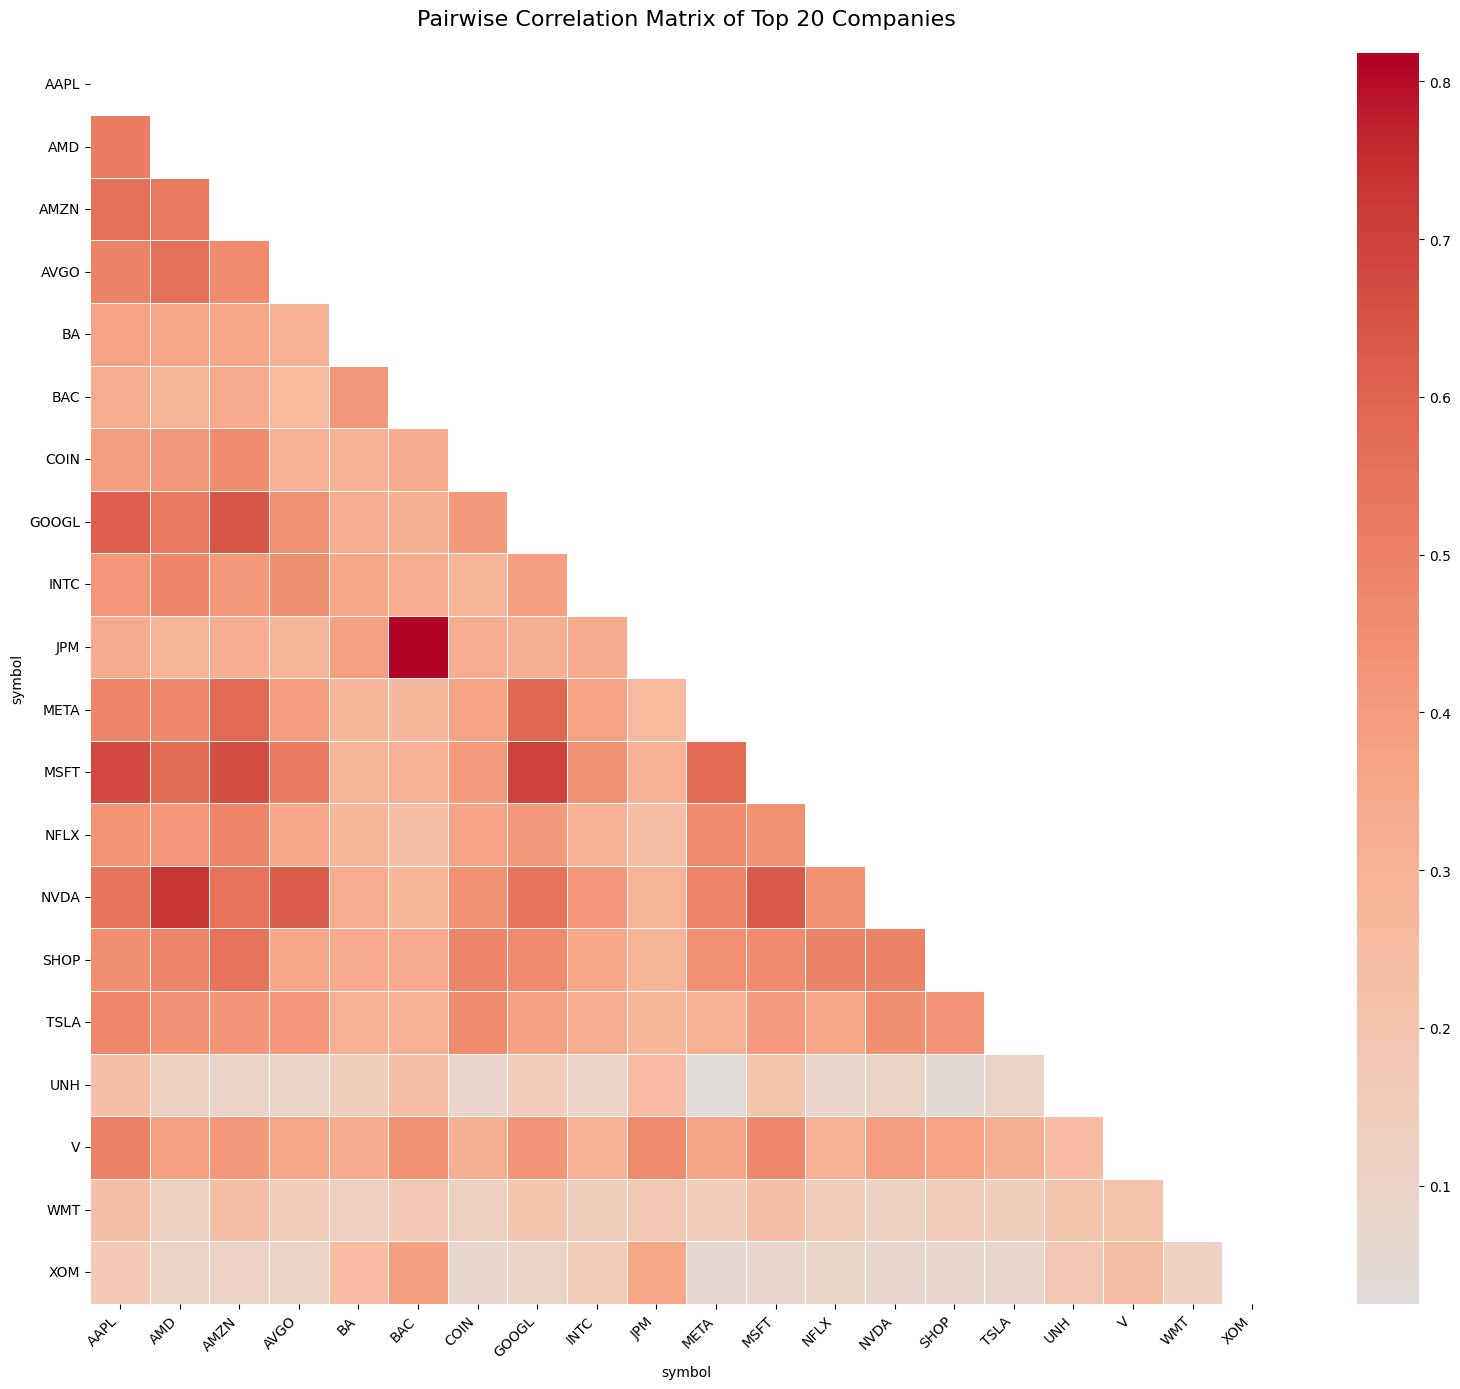

In [54]:
correlation_matrix = daily_returns.corr()

# har bir kompaniyaning daily returnlari o'rtasidagi korrelyatsiya koeffitsiyentlarini hisoblaymiz,
# Correlation aksiyalar bir-biriga qanchalik o'xshash harakat qilishini o'lchaydi va pairs trading hamda sektor tahlillari uchun asos bo'lib xizmat qiladi
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True, annot=False, linewidths=0.5)
plt.title('Pairwise Correlation Matrix of Top 20 Companies', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

4.c


TOP 10 MOST CORRELATED PAIRS:
--------------------------------------------------
 1. JPM - BAC: 0.8181
 2. NVDA - AMD: 0.7342
 3. MSFT - GOOGL: 0.6962
 4. MSFT - AAPL: 0.6808
 5. MSFT - AMZN: 0.6672
 6. GOOGL - AMZN: 0.6421
 7. NVDA - MSFT: 0.6290
 8. NVDA - AVGO: 0.6229
 9. AAPL - GOOGL: 0.6144
10. GOOGL - META: 0.5928


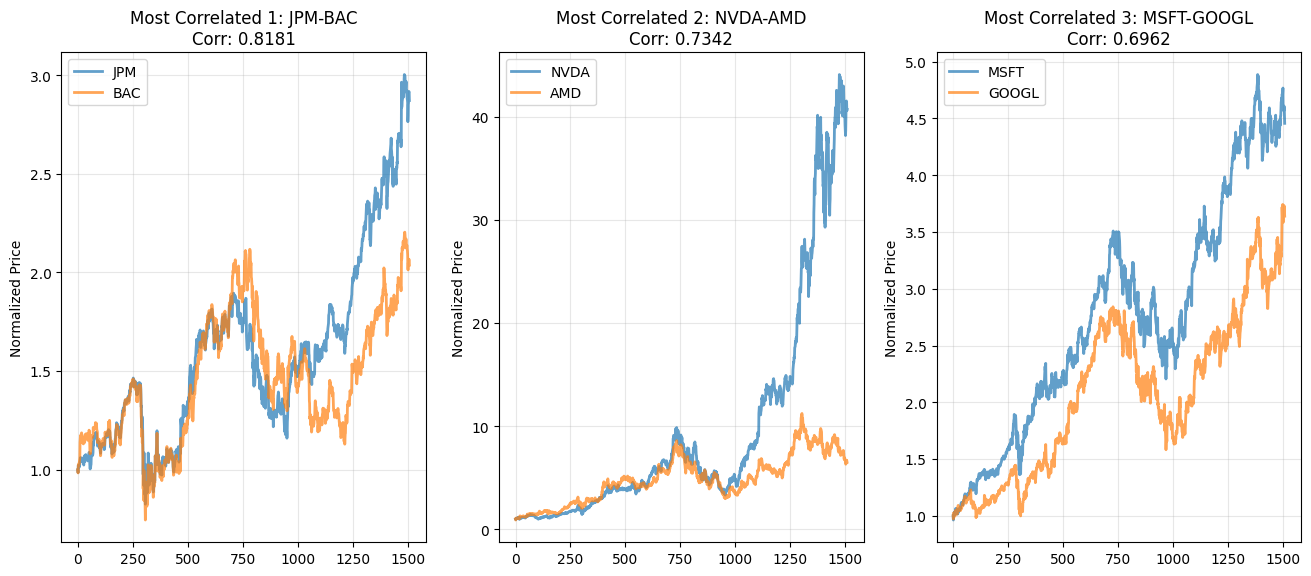

In [13]:
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
plt.figure(figsize=(16, 14))
# I shoud remove self-correlations (where correlation = 1.0) and duplicates
corr_pairs = corr_pairs[corr_pairs < 0.999].drop_duplicates()

# 10 most correlated pairs
top_10_pairs = corr_pairs.head(10)

print("\nTOP 10 MOST CORRELATED PAIRS:")
print("-" * 50)
for i, (pair, corr_value) in enumerate(top_10_pairs.items(), 1):
  stock1, stock2 = pair
  print(f"{i:2d}. {stock1} - {stock2}: {corr_value:.4f}")

# Plot top 3 most correlated pairs, just to see visually, 3 seemed enough
top_3_pairs = list(top_10_pairs.head(3).items())
for i, (pair, corr) in enumerate(top_3_pairs, 1):
  plt.subplot(2, 3, i)
  stock1, stock2 = pair
 # Normalizing is highly recommended for better comparison (start at 1.0)
  stock1_norm = closing_prices[stock1] / closing_prices[stock1].iloc[0]
  stock2_norm = closing_prices[stock2] / closing_prices[stock2].iloc[0]

  plt.plot(stock1_norm.values, label=f'{stock1}', alpha=0.7, linewidth=2)
  plt.plot(stock2_norm.values, label=f'{stock2}', alpha=0.7, linewidth=2)
  plt.title(f'Most Correlated {i}: {stock1}-{stock2}\nCorr: {corr:.4f}', fontsize=12)
  plt.legend()
  plt.ylabel('Normalized Price')
  plt.grid(True, alpha=0.3)



TOP 10 LEAST CORRELATED PAIRS:
--------------------------------------------------
 1. UNH - META: 0.0252
 2. SHOP - UNH: 0.0527
 3. META - XOM: 0.0561
 4. XOM - SHOP: 0.0660
 5. COIN - XOM: 0.0701
 6. MSFT - XOM: 0.0713
 7. TSLA - XOM: 0.0742
 8. XOM - NVDA: 0.0749
 9. UNH - NFLX: 0.0788
10. COIN - UNH: 0.0833


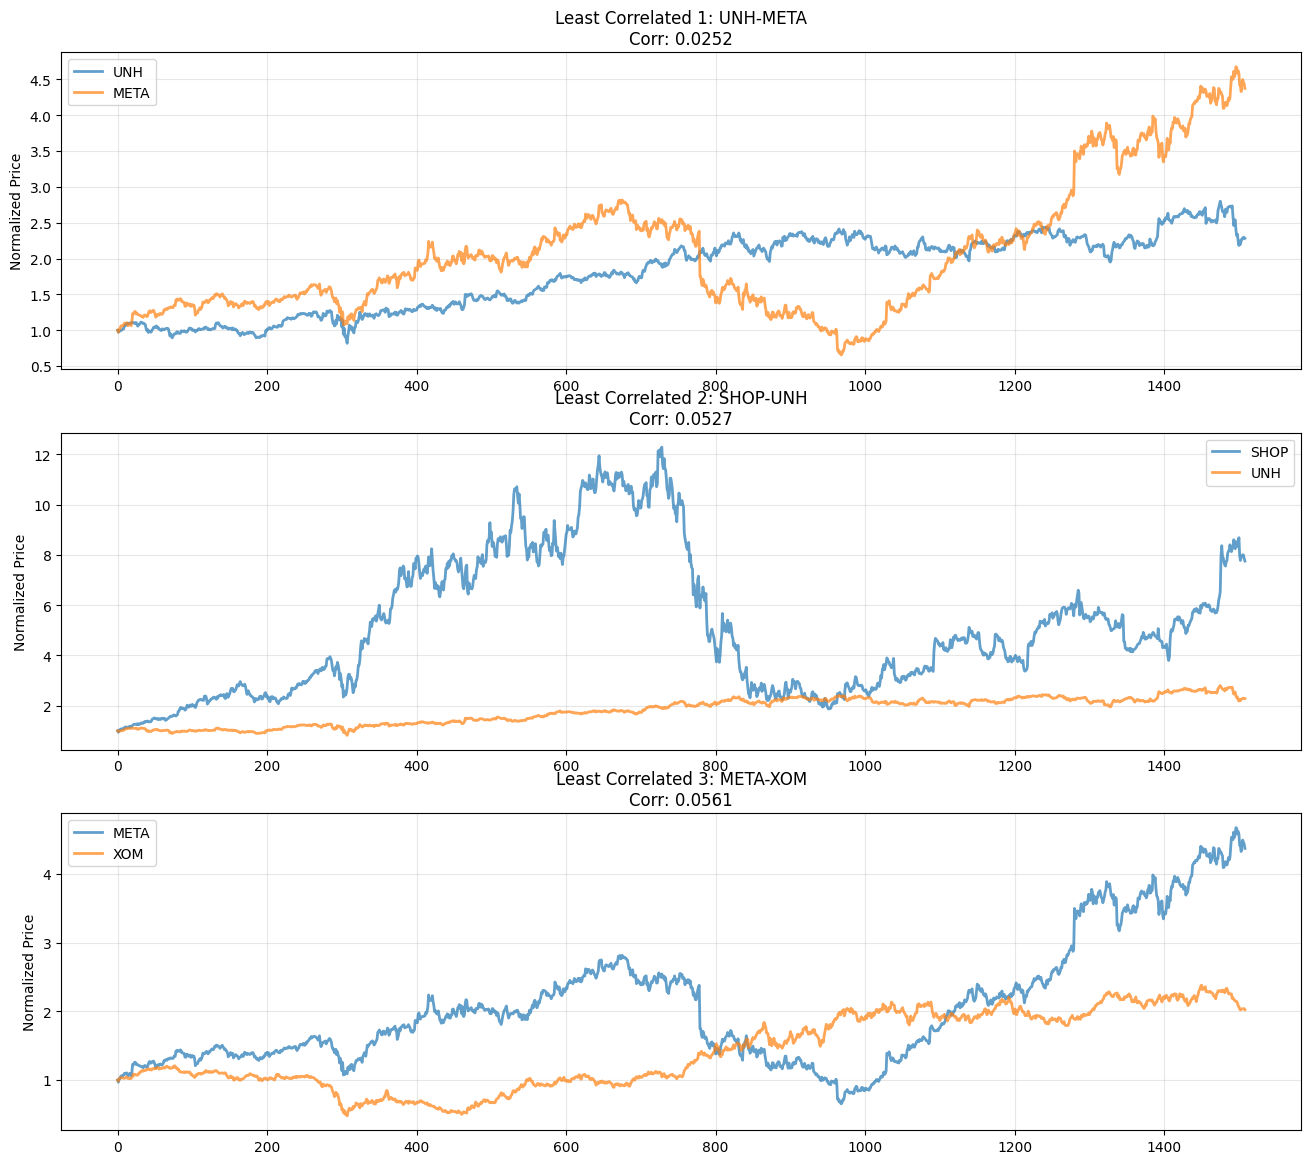

In [14]:
# For least correlated pairs
plt.figure(figsize=(16, 14))
corr_pairs_asc = correlation_matrix.unstack().sort_values(ascending=True)
# Remove self-correlations and duplicates
corr_pairs_asc = corr_pairs_asc[corr_pairs_asc > -0.999].drop_duplicates()

# 10 least correlated pairs
bottom_10_pairs = corr_pairs_asc.head(10)

print("\nTOP 10 LEAST CORRELATED PAIRS:")
print("-" * 50)
for i, ((stock1, stock2), corr) in enumerate(bottom_10_pairs.items(), 1):
  print(f"{i:2d}. {stock1} - {stock2}: {corr:.4f}")

# Plot least correlated pairs
for i, ((stock1, stock2), corr) in enumerate(bottom_10_pairs.head(3).items(), 1):
  plt.subplot(3, 1, i)

  stock1_norm = closing_prices[stock1] / closing_prices[stock1].iloc[0]
  stock2_norm = closing_prices[stock2] / closing_prices[stock2].iloc[0]

  plt.plot(stock1_norm.values, label=f'{stock1}', alpha=0.7, linewidth=2)
  plt.plot(stock2_norm.values, label=f'{stock2}', alpha=0.7, linewidth=2)
  plt.title(f'Least Correlated {i}: {stock1}-{stock2}\nCorr: {corr:.4f}', fontsize=12)
  plt.legend()
  plt.ylabel('Normalized Price')
  plt.grid(True, alpha=0.3)

4.d

Number of within-sector pairs: 31
Number of between-sector pairs: 159

Average correlation within sector: 0.493
Average correlation between sectors: 0.31

Mann–Whitney U test — U = 4144.00, p = 1.021e-09


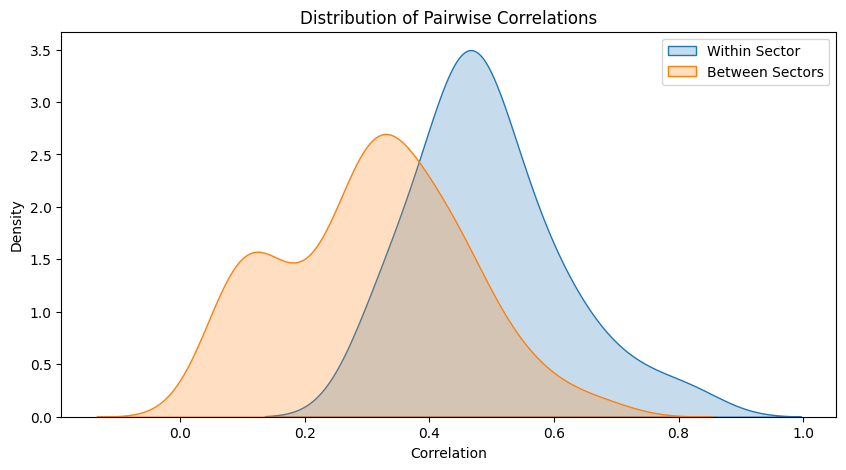

Result: Stocks within the same sector show significantly higher correlations.


In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import mannwhitneyu
corr_matrix = daily_returns.corr(method='pearson')

ticker_col = 'Ticker'
sector_col = 'Sector'
sector_map = securities.set_index(ticker_col)[sector_col].to_dict()

pairs = []
for t1, t2 in combinations(corr_matrix.columns, 2):
  r = corr_matrix.loc[t1, t2]
  s1, s2 = sector_map.get(t1, 'Unknown'), sector_map.get(t2, 'Unknown')
  same_sector = (s1 == s2) and (s1 != 'Unknown')
  pairs.append({'Stock1': t1, 'Stock2': t2, 'Corr': r, 'Sector1': s1, 'Sector2': s2, 'SameSector': same_sector})

pairs_df = pd.DataFrame(pairs)

within = pairs_df.loc[pairs_df['SameSector'], 'Corr'].dropna()
between = pairs_df.loc[~pairs_df['SameSector'], 'Corr'].dropna()

print(f"Number of within-sector pairs: {len(within)}")
print(f"Number of between-sector pairs: {len(between)}")

print("\nAverage correlation within sector:", round(within.mean(), 3))
print("Average correlation between sectors:", round(between.mean(), 3))

u_stat, p_value = mannwhitneyu(within, between, alternative='greater')
print(f"\nMann–Whitney U test — U = {u_stat:.2f}, p = {p_value:.4g}")


plt.figure(figsize=(10,5))
sns.kdeplot(within, fill=True, label='Within Sector')
sns.kdeplot(between, fill=True, label='Between Sectors')
plt.xlabel('Correlation')
plt.title('Distribution of Pairwise Correlations')
plt.legend()
plt.show()

if p_value < 0.05:
  print("Result: Stocks within the same sector show significantly higher correlations.")
else:
  print("Result: No statistically significant difference between within- and between-sector correlations.")


Bu bo'limda kompaniya juftliklari bir xil sektor va turli sektor guruhlariga ajratildi. Har bir juftlik uchun daily returns correlation qiymati olindi. Keyin bir xil sektor ichidagi correlationlar bilan turli sektorlar orasidagi correlationlar taqqoslandi. Mann-Whitney U testi yordamida bu farq statistik jihatdan ahamiyatlimi yoki yo'qligi tekshirildi. Agar p-value 0.05 dan kichik bo'lsa, bir xil sektor kompaniyalari o'zaro kuchliroq bog'langan degan xulosaga kelinadi.

### 5. Distributional Analysis of Daily Price Movements

In [57]:
print(f"Analyzing distribution of daily returns for {len(daily_returns.columns)} companies")
print(f"Time period: {len(daily_returns)} trading days")

clean_returns = daily_returns.replace([np.inf, -np.inf], np.nan).dropna()

returns_stats = clean_returns.describe()
print(f"\nBasic statistics of daily returns:")
print(returns_stats.round(6))

#Bu kod daily returns ma'lumotlarini tozalaydi, noto'g'ri (inf) qiymatlarni olib tashlaydi va
# returnlarning asosiy statistik ko'rsatkichlarini hisoblaydi.

Analyzing distribution of daily returns for 20 companies
Time period: 934 trading days

Basic statistics of daily returns:
symbol        AAPL         AMD        AMZN        AVGO          BA  \
count   934.000000  934.000000  934.000000  934.000000  934.000000   
mean      0.000851    0.000985    0.000559    0.002106   -0.000122   
std       0.016473    0.031945    0.022616    0.024784    0.022807   
min      -0.058680   -0.138688   -0.140494   -0.103521   -0.104701   
25%      -0.008024   -0.017639   -0.011352   -0.011537   -0.012029   
50%       0.001180   -0.000704    0.000315    0.000738   -0.000115   
75%       0.010051    0.019904    0.012793    0.013796    0.012493   
max       0.088975    0.142690    0.135359    0.244326    0.094630   

symbol         BAC        COIN       GOOGL        INTC         JPM  \
count   934.000000  934.000000  934.000000  934.000000  934.000000   
mean      0.000346    0.001299    0.000764   -0.000824    0.000710   
std       0.017004    0.056328    0.

Finance'da return degani:
Aktiv (aksiya) qiymatining ma'lum davrdagi foiz o'zgarishi.

Text(0.05, 0.95, 'Mean: 0.0008\nStd: 0.0233\nSkew: 0.14\nKurtosis: 2.27')

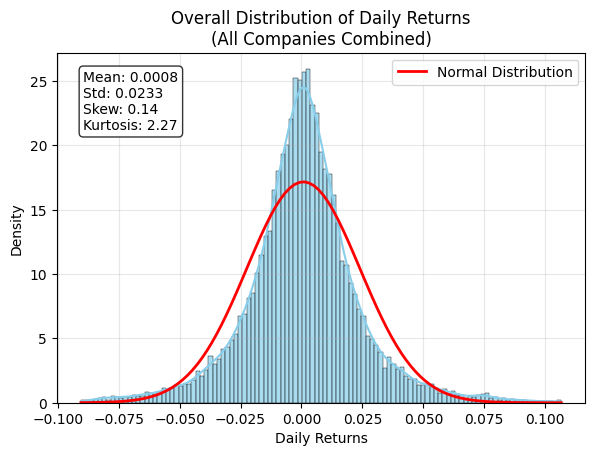

In [58]:
plt.figure(figsize=(15, 10))
from scipy import stats
from scipy.stats import norm

all_returns = clean_returns.values.flatten()
all_returns = all_returns[~np.isnan(all_returns)]

# Recommended to remove extreme outliers for better visualization (keep 99% of data)
q_low = np.percentile(all_returns, 0.5)
q_high = np.percentile(all_returns, 99.5)
filtered_returns = all_returns[(all_returns >= q_low) & (all_returns <= q_high)]

plt.subplot(2, 2, 1)

sns.histplot(filtered_returns, kde=True, stat='density', alpha=0.7, color='skyblue')
# Overlay normal distribution with same mean and std so we can compare visually
from scipy.stats import norm
x = np.linspace(filtered_returns.min(), filtered_returns.max(), 100)
plt.plot(x, norm.pdf(x, filtered_returns.mean(), filtered_returns.std()),
         'r-', linewidth=2, label='Normal Distribution')
plt.title('Overall Distribution of Daily Returns\n(All Companies Combined)')
plt.xlabel('Daily Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

skewness = stats.skew(filtered_returns)
kurtosis = stats.kurtosis(filtered_returns)
plt.text(0.05, 0.95, f'Mean: {filtered_returns.mean():.4f}\nStd: {filtered_returns.std():.4f}\nSkew: {skewness:.2f}\nKurtosis: {kurtosis:.2f}',
transform=plt.gca().transAxes, verticalalignment='top',
bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

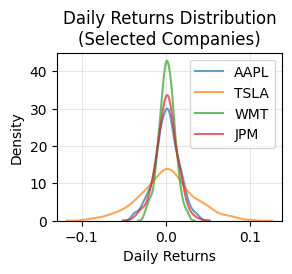

In [59]:
plt.subplot(2, 2, 2)

sample_companies = ['AAPL', 'TSLA', 'WMT', 'JPM']

for i, company in enumerate(sample_companies):
  if company in clean_returns.columns:
    returns_data = clean_returns[company].dropna()

    q_low = np.percentile(returns_data, 1)
    q_high = np.percentile(returns_data, 99)
    filtered_data = returns_data[(returns_data >= q_low) & (returns_data <= q_high)]

    sns.kdeplot(filtered_data, label=company, alpha=0.7)
plt.title('Daily Returns Distribution\n(Selected Companies)')
plt.xlabel('Daily Returns')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

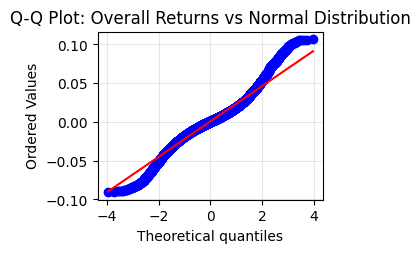

In [60]:
plt.subplot(2, 2, 3)

stats.probplot(filtered_returns, dist="norm", plot=plt)
plt.title('Q-Q Plot: Overall Returns vs Normal Distribution')
plt.grid(True, alpha=0.3)

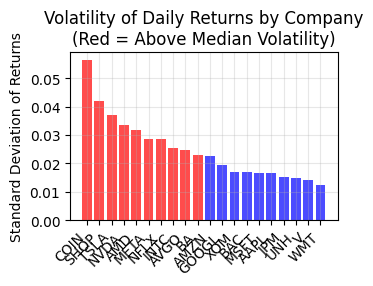

In [20]:
plt.subplot(2, 2, 4)

volatility = clean_returns.std().sort_values(ascending=False)

colors = ['red' if vol > volatility.median() else 'blue' for vol in volatility]
plt.bar(range(len(volatility)), volatility.values, color=colors, alpha=0.7)
plt.xticks(range(len(volatility)), volatility.index, rotation=45, ha='right')
plt.title('Volatility of Daily Returns by Company\n(Red = Above Median Volatility)')
plt.ylabel('Standard Deviation of Returns')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Exploratory Visualization

Agar tadqiqot boshida AAPL, TSLA, WMT, JPM va NVDA ga bir xil pul tikkanimizda,
qaysi biri ko'proq daromad bergan bo'lardi?

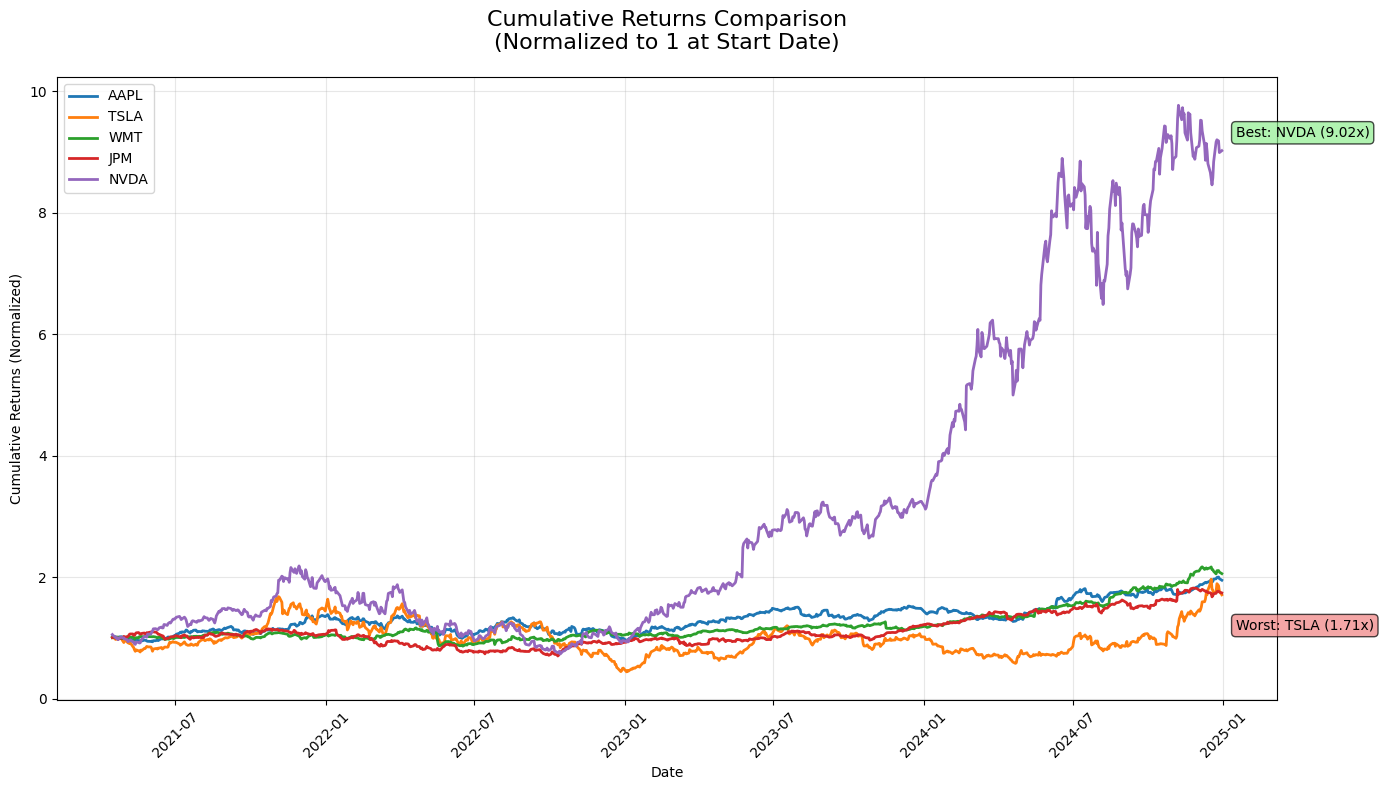


Cumulative Returns (Final):
  AAPL: +95.1%
  TSLA: +71.0%
  WMT: +105.9%
  JPM: +74.2%
  NVDA: +802.0%


In [62]:
cumulative_returns = (1 + daily_returns).cumprod()

selected_companies = ['AAPL', 'TSLA', 'WMT', 'JPM', 'NVDA']  # Tech, High-growth, Stable, Financial, Semiconductor

plt.figure(figsize=(14, 8))

for company in selected_companies:
  if company in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[company], label=company, linewidth=2)

plt.title('Cumulative Returns Comparison\n(Normalized to 1 at Start Date)', fontsize=16, pad=20)
plt.xlabel('Date')
plt.ylabel('Cumulative Returns (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

end_returns = cumulative_returns.iloc[-1][selected_companies]
best_performer = end_returns.idxmax()
worst_performer = end_returns.idxmin()

plt.annotate(f'Best: {best_performer} ({end_returns[best_performer]:.2f}x)',
            xy=(cumulative_returns.index[-1], end_returns[best_performer]),
                        xytext=(10, 10), textcoords='offset points',
                                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
plt.annotate(f'Worst: {worst_performer} ({end_returns[worst_performer]:.2f}x)',
            xy=(cumulative_returns.index[-1], end_returns[worst_performer]),
                        xytext=(10, -25), textcoords='offset points',
                                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightcoral', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\nCumulative Returns (Final):")
for company in selected_companies:
  if company in cumulative_returns.columns:
    total_return = (cumulative_returns[company].iloc[-1] - 1) * 100
    print(f"  {company}: {total_return:+.1f}%")

#Bu kod har bir kompaniyaning daily returnlarini yig'ib (compound qilib) cumulative returnlarni hisoblaydi va
#vaqt davomida investitsiya qiymati qanday o'zgarganini ko'rsatadi.
#Grafik orqali qaysi kompaniya eng yuqori va eng past umumiy daromad bergani aniqlanadi hamda yakuniy foiz returnlar hisoblanadi.

Qaysi aksiyalar xavfliroq (volatile), qaysilari barqarorroq ekanligini aniqlash.

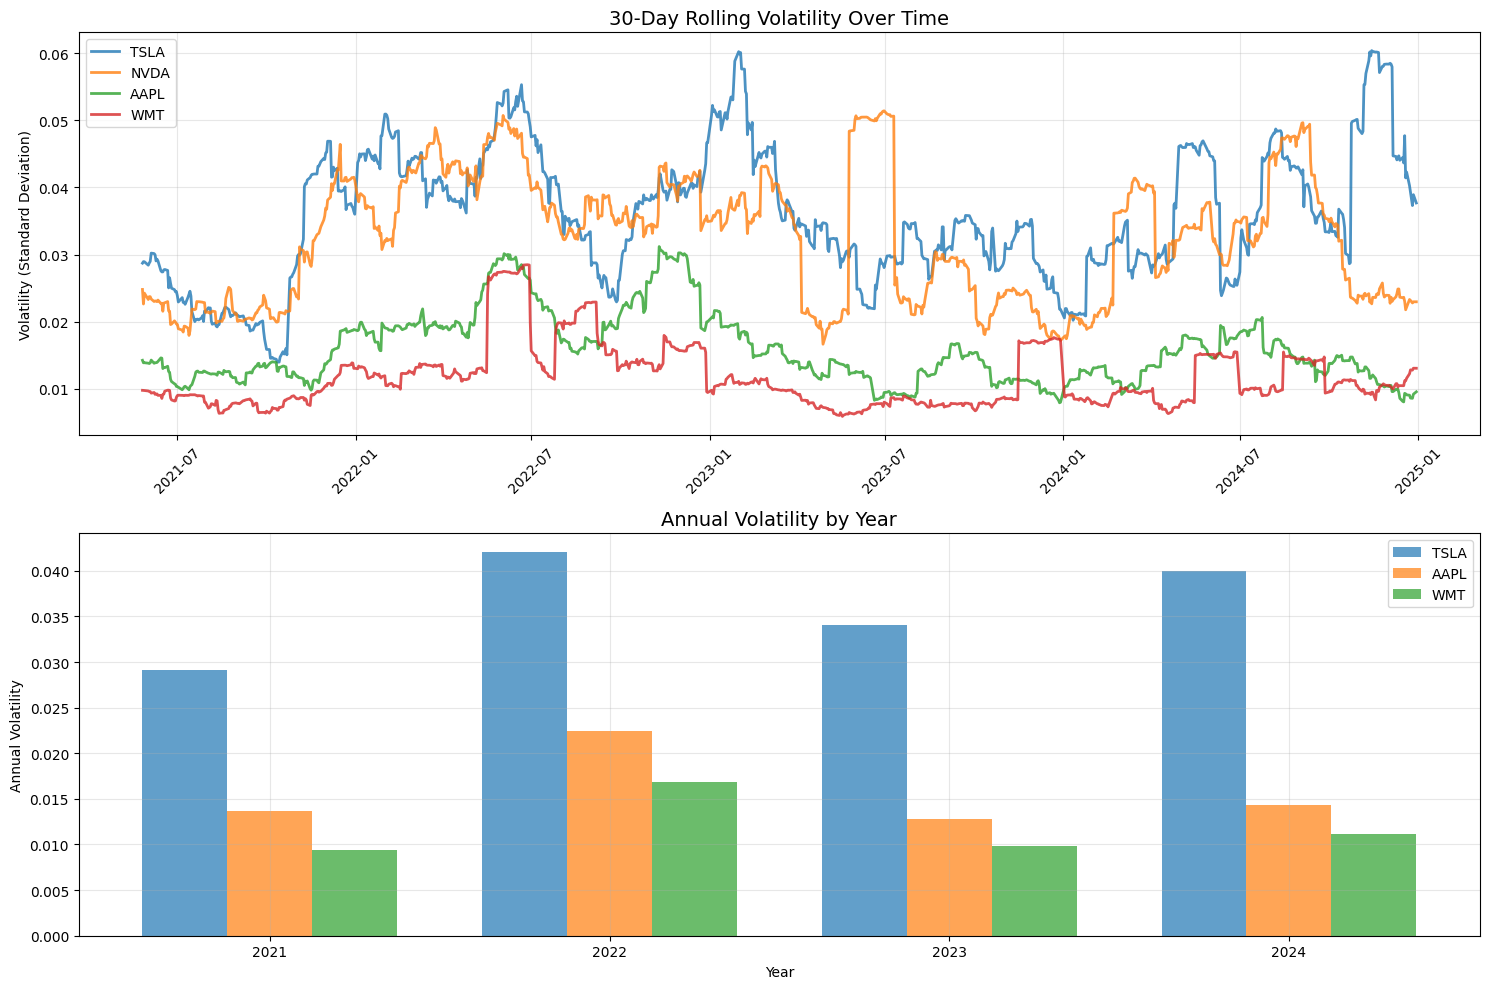


Volatility Insights:
  Most volatile stock: COIN (0.0563)
  Least volatile stock: WMT (0.0124)


In [63]:
rolling_volatility = daily_returns.rolling(window=30).std()

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
volatility_companies = ['TSLA', 'NVDA', 'AAPL', 'WMT']  # High vol, Tech, Mixed, Low vol
for company in volatility_companies:
  if company in rolling_volatility.columns:
    plt.plot(rolling_volatility.index, rolling_volatility[company],label=company, linewidth=2, alpha=0.8)

plt.title('30-Day Rolling Volatility Over Time', fontsize=14)
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(2, 1, 2)

daily_returns_with_year = daily_returns.copy()
daily_returns_with_year['Year'] = daily_returns_with_year.index.year

annual_volatility = daily_returns_with_year.groupby('Year').std()

plot_companies = ['TSLA', 'AAPL', 'WMT']
years = annual_volatility.index
x_pos = np.arange(len(years))
bar_width = 0.25

for i, company in enumerate(plot_companies):
  if company in annual_volatility.columns:
    plt.bar(x_pos + i * bar_width, annual_volatility[company], bar_width, label=company, alpha=0.7)

plt.title('Annual Volatility by Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Annual Volatility')
plt.xticks(x_pos + bar_width, years)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nVolatility Insights:")
max_vol_company = daily_returns.std().idxmax()
min_vol_company = daily_returns.std().idxmin()
print(f"  Most volatile stock: {max_vol_company} ({daily_returns.std()[max_vol_company]:.4f})")
print(f"  Least volatile stock: {min_vol_company} ({daily_returns.std()[min_vol_company]:.4f})")

#Bu kod kompaniyalarning volatilitysini, ya'ni narxlarning qanchalik
#tebranishini tahlil qiladi. 30 kunlik rolling volatility vaqt davomida risk
#qanday o'zgarganini ko'rsatadi, annual volatility esa yillar kesimida riskni
#taqqoslaydi. Yakunda eng xavfli va eng barqaror aksiyalar aniqlanadi.

/tmp/ipykernel_12195/3480942462.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot([market_index_returns[30:][np.array(regimes[30:]) == 'Bull Market'],


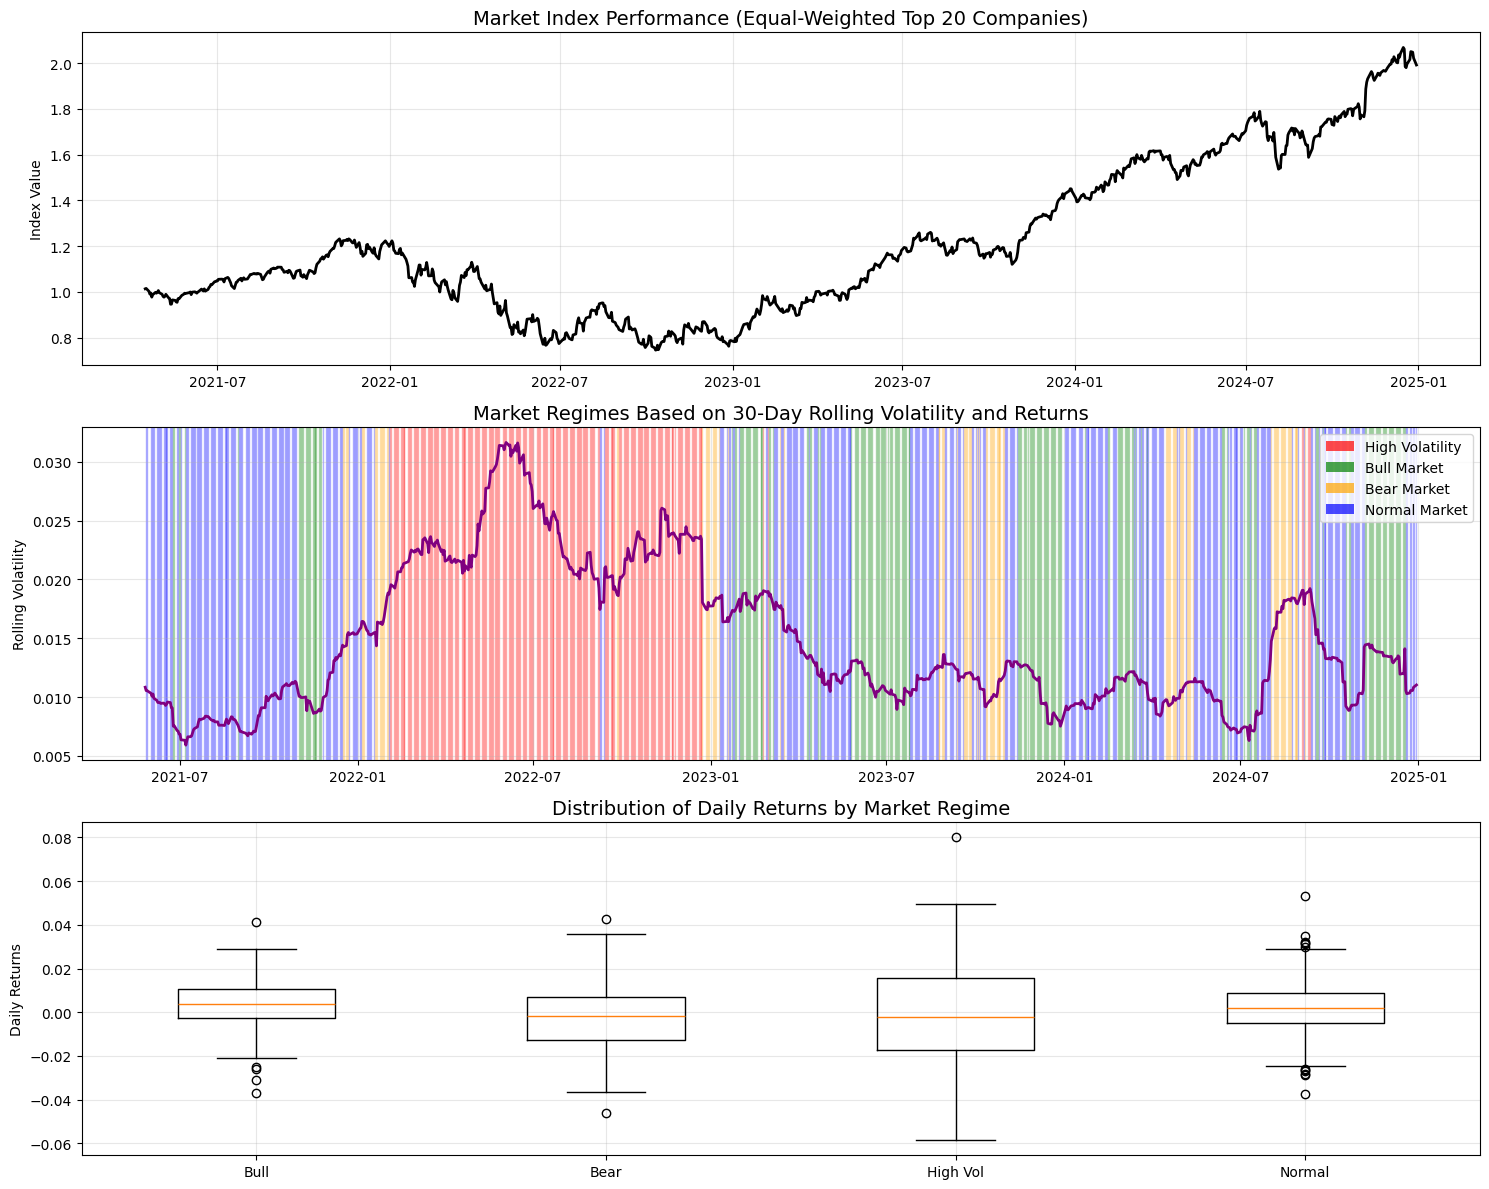


Market Regime Analysis:
  Normal Market: 387 days (42.8%), Avg Return: 0.0017
  High Volatility: 226 days (25.0%), Avg Return: -0.0016
  Bull Market: 191 days (21.1%), Avg Return: 0.0036
  Bear Market: 100 days (11.1%), Avg Return: -0.0020


In [26]:
market_index_returns = daily_returns.mean(axis=1)
market_index = (1 + market_index_returns).cumprod()

rolling_vol = market_index_returns.rolling(window=30).std()
rolling_mean = market_index_returns.rolling(window=30).mean()

def classify_regime(volatility, return_):
  if volatility > rolling_vol.quantile(0.75):
    return 'High Volatility'
  elif return_ > rolling_mean.quantile(0.75):
    return 'Bull Market'
  elif return_ < rolling_mean.quantile(0.25):
    return 'Bear Market'
  else:
    return 'Normal Market'

regimes = []
for i in range(len(rolling_vol)):
  if i >= 30:
    regimes.append(classify_regime(rolling_vol.iloc[i], rolling_mean.iloc[i]))
  else:
    regimes.append('Insufficient Data')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

ax1.plot(market_index.index, market_index.values, color='black', linewidth=2)
ax1.set_title('Market Index Performance (Equal-Weighted Top 20 Companies)', fontsize=14)
ax1.set_ylabel('Index Value')
ax1.grid(True, alpha=0.3)

colors = {'High Volatility': 'red', 'Bull Market': 'green','Bear Market': 'orange', 'Normal Market': 'blue', 'Insufficient Data': 'gray'}

for i in range(30, len(regimes)):
  regime = regimes[i]
  ax2.axvspan(market_index.index[i], market_index.index[i],
              color=colors[regime], alpha=0.3)

ax2.plot(rolling_vol.index, rolling_vol.values, color='purple', linewidth=2)
ax2.set_title('Market Regimes Based on 30-Day Rolling Volatility and Returns', fontsize=14)
ax2.set_ylabel('Rolling Volatility')
ax2.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=regime, alpha=0.7)
                  for regime, color in colors.items() if regime != 'Insufficient Data']
ax2.legend(handles=legend_elements, loc='upper right')


ax3.boxplot([market_index_returns[30:][np.array(regimes[30:]) == 'Bull Market'],
            market_index_returns[30:][np.array(regimes[30:]) == 'Bear Market'],
                        market_index_returns[30:][np.array(regimes[30:]) == 'High Volatility'],
                                    market_index_returns[30:][np.array(regimes[30:]) == 'Normal Market']],
                                               labels=['Bull', 'Bear', 'High Vol', 'Normal'])
ax3.set_title('Distribution of Daily Returns by Market Regime', fontsize=14)
ax3.set_ylabel('Daily Returns')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

regime_series = pd.Series(regimes[30:], index=market_index.index[30:])
regime_counts = regime_series.value_counts()
print(f"\nMarket Regime Analysis:")
for regime, count in regime_counts.items():
  percentage = (count / len(regime_series)) * 100
  avg_return = market_index_returns[30:][regime_series == regime].mean()
  print(f"  {regime}: {count} days ({percentage:.1f}%), Avg Return: {avg_return:.4f}")

Bu bo'limda barcha kompaniyalar returnlaridan foydalanib sun'iy bozor indeksi yaratildi. Keyin 30 kunlik rolling return va rolling volatility hisoblandi. Shu ko'rsatkichlar asosida bozor kunlari Bull Market, Bear Market, High Volatility va Normal Market rejimlariga ajratildi. Grafiklar orqali bozorning vaqt davomida qanday holatda bo'lgani va har bir rejimda returnlarning qanday taqsimlangani tahlil qilindi.